In [1]:
import numpy as np
print("numpy ok")

numpy ok


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, average_precision_score

from xgboost import XGBClassifier

In [3]:
credit_df = pd.read_csv("../data/raw/creditcard.csv")
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

In [4]:
X_credit = credit_df.drop("Class", axis=1)
y_credit = credit_df["Class"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_credit, y_credit,
    test_size=0.2,
    stratify=y_credit,
    random_state=42
)

In [5]:
X_fraud = fraud_df.drop("class", axis=1)
y_fraud = fraud_df["class"]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fraud, y_fraud,
    test_size=0.2,
    stratify=y_fraud,
    random_state=42
)

In [6]:
lr_credit = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_credit.fit(Xc_train, yc_train)

pred_lr_credit = lr_credit.predict(Xc_test)
proba_lr_credit = lr_credit.predict_proba(Xc_test)[:, 1]

c:\Users\Hp\Desktop\Projects\10Academy\fraud-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
xgb_credit = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss"
)

xgb_credit.fit(Xc_train, yc_train)

pred_xgb_credit = xgb_credit.predict(Xc_test)
proba_xgb_credit = xgb_credit.predict_proba(Xc_test)[:, 1]

In [9]:
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

In [10]:
fraud_df['time_diff'] = (fraud_df['purchase_time'] - fraud_df['signup_time']).dt.total_seconds()

fraud_df['hour'] = fraud_df['purchase_time'].dt.hour
fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.dayofweek

In [11]:
fraud_df = fraud_df.drop(['signup_time', 'purchase_time'], axis=1)

In [12]:
fraud_df.dtypes

user_id             int64
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
time_diff         float64
hour                int32
day_of_week         int32
dtype: object

In [13]:
fraud_df = pd.get_dummies(fraud_df, drop_first=True)

MemoryError: Unable to allocate 19.4 GiB for an array with shape (151112, 137956) and data type bool

In [14]:
fraud_df = fraud_df.drop(['device_id', 'ip_address'], axis=1)

In [16]:
fraud_df = fraud_df.select_dtypes(include=['number'])

In [17]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression

lr_fraud = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_fraud.fit(Xf_train, yf_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Non-numeric and high-cardinality features were removed to prevent dimensional explosion and ensure model stability. Only engineered numerical features were retained for modeling.

In [20]:
fraud_df.columns

Index(['user_id', 'purchase_value', 'age', 'class', 'time_diff', 'hour',
       'day_of_week'],
      dtype='str')

In [21]:
fraud_df.head()

,user_id,purchase_value,age,class,time_diff,hour,day_of_week
0,22058,34,39,0,4506682.0,2,5
1,333320,16,53,0,17944.0,1,0
2,1359,15,53,1,1.0,18,3
3,150084,44,41,0,492085.0,13,0
4,221365,39,45,0,4361461.0,18,2


In [22]:
fraud_df.columns
fraud_df.head()

,user_id,purchase_value,age,class,time_diff,hour,day_of_week
0,22058,34,39,0,4506682.0,2,5
1,333320,16,53,0,17944.0,1,0
2,1359,15,53,1,1.0,18,3
3,150084,44,41,0,492085.0,13,0
4,221365,39,45,0,4361461.0,18,2


In [23]:
X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

In [24]:
from sklearn.model_selection import train_test_split

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression

lr_fraud = LogisticRegression(max_iter=1000, class_weight="balanced")

lr_fraud.fit(Xf_train, yf_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [26]:
pred_lr_fraud = lr_fraud.predict(Xf_test)
proba_lr_fraud = lr_fraud.predict_proba(Xf_test)[:, 1]

In [27]:
from sklearn.metrics import f1_score, confusion_matrix, average_precision_score

In [28]:
f1 = f1_score(yf_test, pred_lr_fraud)
print("F1 Score:", f1)

F1 Score: 0.27369298062903563


In [29]:
auc_pr = average_precision_score(yf_test, proba_lr_fraud)
print("AUC-PR:", auc_pr)

AUC-PR: 0.3684197585954444


In [30]:
print(confusion_matrix(yf_test, pred_lr_fraud))

[[17791  9602]
 [  859  1971]]


In [31]:
from xgboost import XGBClassifier

In [32]:
scale_pos_weight = yf_train.value_counts()[0] / yf_train.value_counts()[1]

In [33]:
xgb_fraud = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"
)

xgb_fraud.fit(Xf_train, yf_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [34]:
pred_xgb_fraud = xgb_fraud.predict(Xf_test)
proba_xgb_fraud = xgb_fraud.predict_proba(Xf_test)[:, 1]

In [35]:
from sklearn.metrics import f1_score, average_precision_score, confusion_matrix

print("F1:", f1_score(yf_test, pred_xgb_fraud))
print("AUC-PR:", average_precision_score(yf_test, proba_xgb_fraud))
print(confusion_matrix(yf_test, pred_xgb_fraud))

F1: 0.6678515885358809
AUC-PR: 0.5816363898051131
[[27225   168]
 [ 1327  1503]]


In [36]:
import pandas as pd

fraud_results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "F1 Score": [
        f1_score(yf_test, pred_lr_fraud),
        f1_score(yf_test, pred_xgb_fraud)
    ],
    "AUC-PR": [
        average_precision_score(yf_test, proba_lr_fraud),
        average_precision_score(yf_test, proba_xgb_fraud)
    ]
})

fraud_results

,Model,F1 Score,AUC-PR
0,Logistic Regression,0.273693,0.368420
1,XGBoost,0.667852,0.581636


In [38]:
from sklearn.linear_model import LogisticRegression

lr_credit = LogisticRegression(max_iter=1000, class_weight="balanced")

lr_credit.fit(Xc_train, yc_train)

c:\Users\Hp\Desktop\Projects\10Academy\fraud-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [39]:
pred_lr_credit = lr_credit.predict(Xc_test)
proba_lr_credit = lr_credit.predict_proba(Xc_test)[:, 1]

In [40]:
from sklearn.metrics import f1_score, average_precision_score, confusion_matrix

print("F1:", f1_score(yc_test, pred_lr_credit))
print("AUC-PR:", average_precision_score(yc_test, proba_lr_credit))
print(confusion_matrix(yc_test, pred_lr_credit))

F1: 0.0996126175982291
AUC-PR: 0.7175788690504598
[[55245  1619]
 [    8    90]]


In [41]:
from xgboost import XGBClassifier

In [42]:
scale_pos_weight = yc_train.value_counts()[0] / yc_train.value_counts()[1]

In [43]:
xgb_credit = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"
)

xgb_credit.fit(Xc_train, yc_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [44]:
pred_xgb_credit = xgb_credit.predict(Xc_test)
proba_xgb_credit = xgb_credit.predict_proba(Xc_test)[:, 1]

In [45]:
print("F1:", f1_score(yc_test, pred_xgb_credit))
print("AUC-PR:", average_precision_score(yc_test, proba_xgb_credit))
print(confusion_matrix(yc_test, pred_xgb_credit))

F1: 0.7336244541484717
AUC-PR: 0.8566634160804915
[[56817    47]
 [   14    84]]


In [46]:
import pandas as pd
from sklearn.metrics import f1_score, average_precision_score

credit_results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "F1 Score": [
        f1_score(yc_test, pred_lr_credit),
        f1_score(yc_test, pred_xgb_credit)
    ],
    "AUC-PR": [
        average_precision_score(yc_test, proba_lr_credit),
        average_precision_score(yc_test, proba_xgb_credit)
    ]
})

credit_results

,Model,F1 Score,AUC-PR
0,Logistic Regression,0.099613,0.717579
1,XGBoost,0.733624,0.856663


In [47]:
final_results = pd.DataFrame({
    "Dataset": [
        "Fraud", "Fraud",
        "Credit Card", "Credit Card"
    ],
    "Model": [
        "Logistic Regression", "XGBoost",
        "Logistic Regression", "XGBoost"
    ],
    "F1 Score": [
        f1_score(yf_test, pred_lr_fraud),
        f1_score(yf_test, pred_xgb_fraud),
        f1_score(yc_test, pred_lr_credit),
        f1_score(yc_test, pred_xgb_credit)
    ],
    "AUC-PR": [
        average_precision_score(yf_test, proba_lr_fraud),
        average_precision_score(yf_test, proba_xgb_fraud),
        average_precision_score(yc_test, proba_lr_credit),
        average_precision_score(yc_test, proba_xgb_credit)
    ]
})

final_results

,Dataset,Model,F1 Score,AUC-PR
0,Fraud,Logistic Regression,0.273693,0.368420
1,Fraud,XGBoost,0.667852,0.581636
2,Credit Card,Logistic Regression,0.099613,0.717579
3,Credit Card,XGBoost,0.733624,0.856663


In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

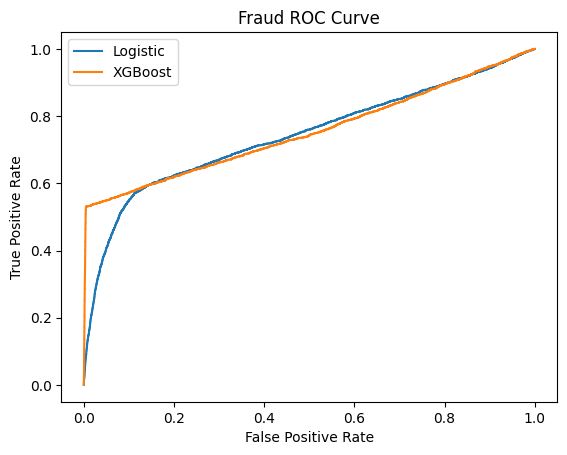

In [49]:
fpr1, tpr1, _ = roc_curve(yf_test, proba_lr_fraud)
fpr2, tpr2, _ = roc_curve(yf_test, proba_xgb_fraud)

plt.plot(fpr1, tpr1, label="Logistic")
plt.plot(fpr2, tpr2, label="XGBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fraud ROC Curve")
plt.legend()
plt.show()

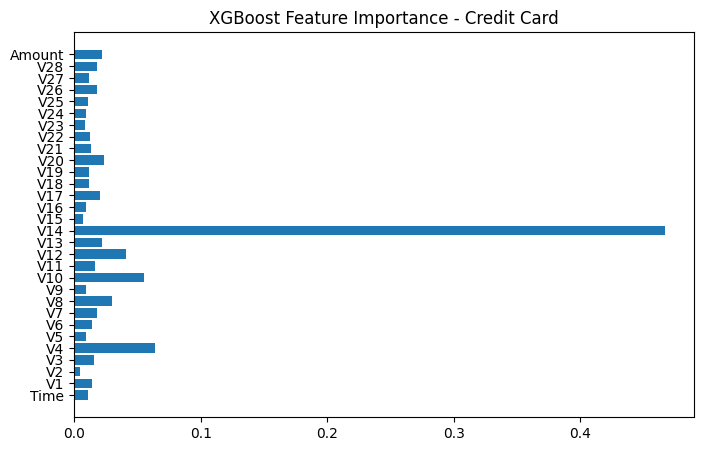

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(X_credit.columns, xgb_credit.feature_importances_)
plt.title("XGBoost Feature Importance - Credit Card")
plt.show()

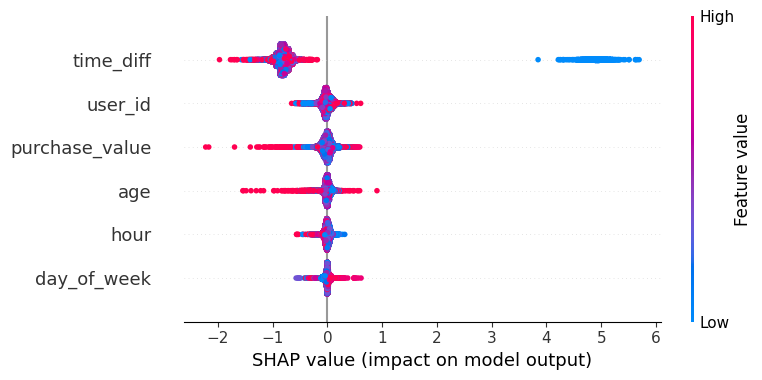

In [51]:
import shap

explainer = shap.TreeExplainer(xgb_fraud)
shap_values = explainer.shap_values(Xf_test)

shap.summary_plot(shap_values, Xf_test)